# Import basic libraries

In [61]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

Load dataset

In [62]:
!pip install ucimlrepo

In [63]:
from ucimlrepo import fetch_ucirepo

# fetch dataset
dataset = fetch_ucirepo(id=294)

In [64]:
dataset.data.keys()

dict_keys(['ids', 'features', 'targets', 'original', 'headers'])

In [65]:
dataset.data.headers

Index(['AT', 'V', 'AP', 'RH', 'PE'], dtype='object')

In [66]:
df = pd.DataFrame(dataset.data.features, columns=dataset.data.headers[:-1])
df['PE'] = dataset.data.targets
df.head()

,AT,V,AP,RH,PE
0,14.96,41.76,1024.07,73.17,463.26
1,25.18,62.96,1020.04,59.08,444.37
2,5.11,39.40,1012.16,92.14,488.56
3,20.86,57.32,1010.24,76.64,446.48
4,10.82,37.50,1009.23,96.62,473.90


In [67]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9568 entries, 0 to 9567
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   AT      9568 non-null   float64
 1   V       9568 non-null   float64
 2   AP      9568 non-null   float64
 3   RH      9568 non-null   float64
 4   PE      9568 non-null   float64
dtypes: float64(5)
memory usage: 373.9 KB


In [68]:
# Check for missing values
df.isnull().sum()

,0
AT,0
V,0
AP,0
RH,0
PE,0


In [69]:
# Drop duplicate entries
df.drop_duplicates(inplace=True)

Train test split

In [70]:
X = df.drop('PE', axis=1)
y = df['PE']

In [71]:
from sklearn.model_selection import train_test_split

In [72]:
X_train, X_temp, y_train, y_temp = train_test_split(X, y,test_size=0.3, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)

In [73]:
print("Training data size:", X_train.shape)
print("Validation data size:", X_val.shape)
print("Testing data size:", X_test.shape)

Training data size: (6668, 4)
Validation data size: (1429, 4)
Testing data size: (1430, 4)


Feature Scaling

In [74]:
from sklearn.preprocessing import StandardScaler

In [75]:
scaler = StandardScaler()

In [76]:
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

Correlation between features of training set

In [77]:
# Correlation matrix
df_train = pd.DataFrame(X_train_scaled, columns=df.columns[:-1])
corr_matrix = df_train.corr()

In [78]:
print(corr_matrix)

          AT         V        AP        RH
AT  1.000000  0.837999 -0.503252 -0.539952
V   0.837999  1.000000 -0.404055 -0.303884
AP -0.503252 -0.404055  1.000000  0.093333
RH -0.539952 -0.303884  0.093333  1.000000


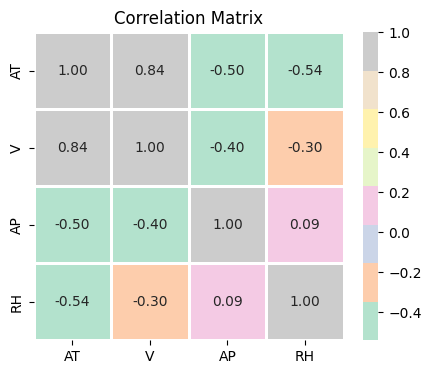

In [79]:
# Create the heatmap
plt.figure(figsize=(5, 4))
sns.heatmap(corr_matrix, annot=True, cmap='Pastel2', fmt='.2f', linewidths=1)
plt.title('Correlation Matrix')
plt.show()

Fit SVM on training data using sklearn

In [80]:
from sklearn.svm import SVR
from sklearn.metrics import mean_squared_error, r2_score

In [81]:
# Initialize a linear SVM
svm_linear = SVR(kernel='linear')

In [82]:
svm_linear.fit(X_train_scaled, y_train)

SVR(kernel='linear')

Hyperparameter Tuning using Sklearn GridSearch

In [83]:
C = [0.01, 0.1, 1, 10, 100]
epsilon = [0.001, 0.01, 0.1, 0.5, 1]

In [84]:
best_mse_linear = float("inf")
best_C_linear = None
best_epsilon_linear = None

for c in C:
    for eps in epsilon:
        model = SVR(kernel='linear', C=c, epsilon=eps)
        model.fit(X_train_scaled, y_train)
        y_val_pred = model.predict(X_val_scaled)
        mse = mean_squared_error(y_val, y_val_pred)
        if mse < best_mse_linear:
            best_mse_linear = mse
            best_C_linear = c
            best_epsilon_linear = eps

print("Best Linear SVR Params:", best_C_linear, best_epsilon_linear)
print("Validation MSE:", best_mse_linear)

Best Linear SVR Params: 1 0.1
Validation MSE: 21.694690865278535


In [85]:
best_C_linear = best_C_linear
best_epsilon_linear = best_epsilon_linear

Fit the model based on the best parameters obtained

In [86]:
best_linear_svm = SVR(kernel='linear', C=best_C_linear, epsilon=best_epsilon_linear)
best_linear_svm.fit(X_train_scaled, y_train)

SVR(C=1, kernel='linear')

In [87]:
y_pred_linear_svm = best_linear_svm.predict(X_test_scaled)

Report performance in terms of Mean Squared Error and R2 score

In [88]:
print("Mean Squared Error:", mean_squared_error(y_test, y_pred_linear_svm))
print("R2 Score:", r2_score(y_test, y_pred_linear_svm))

Mean Squared Error: 22.648338622660948
R2 Score: 0.9230248884975212


Scatter plot of predicted vs actual values for Linear SVM Regressor

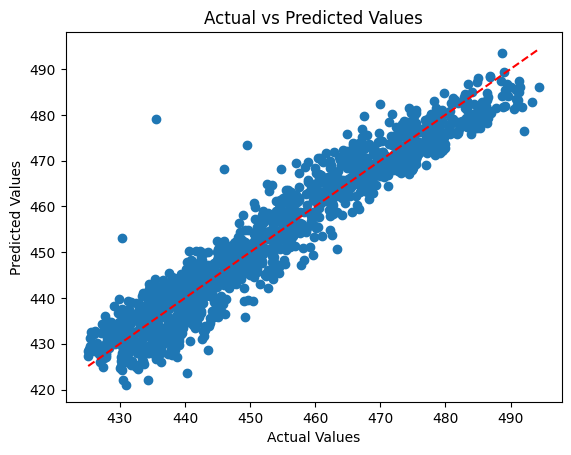

In [89]:
# Scatter plot of predicted vs actual values
plt.scatter(y_test, y_pred_linear_svm)
plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], 'r--')
plt.xlabel('Actual Values')
plt.ylabel('Predicted Values')
plt.title('Actual vs Predicted Values')
plt.show()

In [90]:
svm_rbf = SVR(kernel='rbf')
svm_rbf.fit(X_train_scaled, y_train)

SVR()

Hyperparameter Tuning using Sklearn GridSearchCV

In [91]:
C = [0.1, 1, 10, 100, 1000]
gamma = [0.001, 0.01, 0.1, 1, 10]
epsilon = [0.01, 0.1, 0.5, 1]

In [92]:
best_mse_rbf = float("inf")
best_C_rbf = None
best_epsilon_rbf = None
best_gamma_rbf = None

for c in C:
    for eps in epsilon:
        for gamma_val in gamma:
            model = SVR(kernel='rbf', C=c, epsilon=eps, gamma=gamma_val)
            model.fit(X_train_scaled, y_train)
            y_val_pred = model.predict(X_val_scaled)
            mse = mean_squared_error(y_val, y_val_pred)
            if mse < best_mse_rbf:
                best_mse_rbf = mse
                best_C_rbf = c
                best_epsilon_rbf = eps
                best_gamma_rbf = gamma_val

print("Best RBF SVR Params:", best_C_rbf, best_epsilon_rbf, best_gamma_rbf)
print("Validation MSE:", best_mse_rbf)


Best RBF SVR Params: 100 1 1
Validation MSE: 15.303044951350905


Evaluate RBF SVM regressor using the best values obtained above

In [93]:
best_rbf_svm = SVR(kernel='rbf', C=best_C_rbf, epsilon=best_epsilon_rbf, gamma=best_gamma_rbf)
best_rbf_svm.fit(X_train_scaled, y_train)

SVR(C=100, epsilon=1, gamma=1)

In [94]:
y_pred_rbf_svm = best_rbf_svm.predict(X_test_scaled)

Report performance in terms of Mean Sqaured Error and R2 score

In [95]:
print("Mean Squared Error:", mean_squared_error(y_test, y_pred_rbf_svm))
print("R2 Score:", r2_score(y_test, y_pred_rbf_svm))

Mean Squared Error: 16.485843014479528
R2 Score: 0.9439694175632726


Scatter plot of predicted vs actual values for RBF SVM Regressor

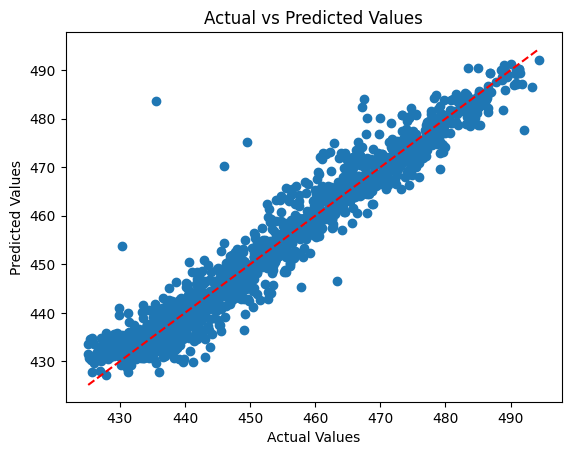

In [96]:
# Scatter plot of predicted vs actual values
plt.scatter(y_test, y_pred_rbf_svm)
plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], 'r--')
plt.xlabel('Actual Values')
plt.ylabel('Predicted Values')
plt.title('Actual vs Predicted Values')
plt.show()